<hr>
<div>
<h2>Initialize Modeling Environment</h2>
<p>Initializes the shared imports, plotting style, and data access used throughout section 04. The policy's hard rules come from <code>retention.policy</code> and the selection logic from <code>retention.optimizer</code>, the same code the agent calls as a tool in section 05.</p>
</div>

In [1]:
# Standard Library
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, 'src')
from retention import data, optimizer as O, policy as P

warnings.filterwarnings('ignore', category = FutureWarning)
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
TEAL = '#1baf7a'
YELLOW = '#eda100'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Output Helpers & Constants
OUTPUTS = Path('outputs')
SEED = 20260921
N_MONTHS = 24
CAMPAIGN_1_MONTH = 13
BUDGET = 40_000
OFFER_LABELS = {'discount': 'Discount', 'device': 'Device credit', 'data': 'Data upgrade'}


def load_output(name):
    return pd.read_parquet(OUTPUTS / f'{name}.parquet')


def money(v):
    return f'−${abs(v):,.0f}' if v < 0 else f'${v:,.0f}'


def save_output(df, name):

    path = OUTPUTS / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>04 · Offer Optimizer</h1>
<p><strong>Purpose:</strong> Decides whom to contact tonight, and with which offer, within a &#36;40,000 budget. It combines section 01's churn risk, section 02's uplift and acceptance, and section 03's reasons into one expected value per customer and offer, and chooses the set that's worth the most.</p>
<p><strong>Architecture:</strong> A first plan built straight from the model estimates promises far more than it delivers. Three guardrails, each grounded in evidence available before launch, turn it into a plan that keeps more customers and spends only what it's allowed; the answer key then scores it against the common practice of contacting the riskiest customers first.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Why</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1 · Eligibility</td><td style="text-align: left; vertical-align: top;">The policy's hard rules, in code</td><td style="text-align: left; vertical-align: top;">Never plan an offer the policy forbids</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2 · Customer value</td><td style="text-align: left; vertical-align: top;">24-month margin from the bill and the churn risk</td><td style="text-align: left; vertical-align: top;">What keeping a customer is worth</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3 · A first plan</td><td style="text-align: left; vertical-align: top;">Greedy selection on the raw estimates</td><td style="text-align: left; vertical-align: top;">What goes wrong when estimates are taken at face value</td></tr>
<tr><td style="text-align: left; vertical-align: top;">4 · Guardrails</td><td style="text-align: left; vertical-align: top;">Evidence gate, average acceptance, exposure budget</td><td style="text-align: left; vertical-align: top;">A plan the evidence supports</td></tr>
<tr><td style="text-align: left; vertical-align: top;">5 · Policy comparison</td><td style="text-align: left; vertical-align: top;">Five policies scored on the answer key</td><td style="text-align: left; vertical-align: top;">The study's main result</td></tr>
<tr><td style="text-align: left; vertical-align: top;">6 · Budget</td><td style="text-align: left; vertical-align: top;">The same comparison from &#36;5,000 to &#36;120,000</td><td style="text-align: left; vertical-align: top;">How much to spend</td></tr>
<tr><td style="text-align: left; vertical-align: top;">7 · Greedy vs exact</td><td style="text-align: left; vertical-align: top;">Integer program on the same candidates</td><td style="text-align: left; vertical-align: top;">Whether the fast rule leaves value behind</td></tr>
<tr><td style="text-align: left; vertical-align: top;">8 · Tonight's plan</td><td style="text-align: left; vertical-align: top;">The plan, with a random holdout</td><td style="text-align: left; vertical-align: top;">Handoff to the agent</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Eligibility</h2>
<p><strong>Purpose:</strong> Applies the offer policy's hard rules to tonight's 75,301 accounts, so every later step works only with offers the policy allows.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Rules.</strong> From <code>offer_policy.md</code>, in <code>retention.policy</code>: never contact do-not-contact accounts or anyone offered something in the past 90 days; the discount needs 6+ months' tenure, no discount accepted in 12 months, and at most one late payment in 3 months; the device credit needs a phone 18+ months old, paid off or within 3 months of it, and no late payments; the data upgrade needs the 15 GB plan.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Most customers are reachable.</strong> 97.1% can be contacted tonight, and 88.4% are eligible for at least one offer: 82% for the discount, 43% for the device credit, and 24% for the data upgrade.</li>
</ol>
</div>

In [4]:
# Apply Eligibility Rules
snapshot = data.load('scoring_snapshot')
churn_scores = load_output('churn_scores')
uplift_scores = load_output('uplift_scores')
reasons = load_output('account_reasons')

allowed = P.eligible(snapshot, N_MONTHS)
eligibility = pd.DataFrame({
    'eligible accounts': allowed.sum(),
    'share of tonight\'s batch': allowed.mean(),
}).rename(index = OFFER_LABELS)
print(f'{P.can_contact(snapshot, N_MONTHS).mean():.1%} of accounts can be contacted tonight · '
      f'{allowed.any(axis = 1).mean():.1%} are eligible for at least one offer')
display(eligibility.style.format({'eligible accounts': '{:,}', 'share of tonight\'s batch': '{:.1%}'}))

97.1% of accounts can be contacted tonight · 88.4% are eligible for at least one offer


,eligible accounts,share of tonight's batch
Discount,"61,939",82.3%
Device credit,"32,500",43.2%
Data upgrade,"18,233",24.2%


<hr>
<div>
<h2>2 · Customer Value</h2>
<p><strong>Purpose:</strong> Estimates what keeping each customer is worth: the margin they'd bring over the next 24 months if they stay, which is what an offer protects.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Margin.</strong> 55% of the service bill: the bill without device installments, which pay for the phone rather than earn margin.</li>
<li style="margin-bottom: 0.7em;"><strong>Expected Months.</strong> Each month's margin counts in proportion to the chance the customer is still there, from the monthly churn rate implied by section 01's 90-day risk, discounted 1% a month.</li>
<li style="margin-bottom: 0.7em;"><strong>Checked.</strong> Against the answer key's true 24-month value.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The estimate is close.</strong> &#36;1,261 on average against &#36;1,203 true, with a correlation of 0.94: the bill carries most of the value, and the churn risk adjusts it modestly.</li>
</ol>
</div>

In [5]:
# Estimate Customer Value
rows = snapshot.merge(churn_scores[['account_id', 'p_churn_90']], on = 'account_id')
rows['value'] = O.customer_value(rows, rows['p_churn_90'])
truth = data.load_answer_key('truth_potential_outcomes').set_index('account_id')
true_value = truth.loc[rows['account_id'], 'clv_24m'].to_numpy()
display(pd.DataFrame({
    'mean estimated value': [rows['value'].mean()], 'mean true value': [true_value.mean()],
    'correlation': [np.corrcoef(rows['value'], true_value)[0, 1]],
}).style.format({'mean estimated value': money, 'mean true value': money, 'correlation': '{:.2f}'}))

,mean estimated value,mean true value,correlation
0,"$1,261","$1,203",0.94


<hr>
<div>
<h2>3 · A First Plan</h2>
<p><strong>Purpose:</strong> Builds the plan the models suggest when taken at face value, and scores it against the answer key, to show why the estimates can't be used as they are.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Expected Value.</strong> For each eligible customer and offer: uplift × customer value − acceptance × offer cost. Uplift and acceptance are section 02's per-customer estimates; the uplift is adjusted by the account's reason from its rep codes, as tested in section 03 (no offer for a move, the matching offer's uplift doubled).</li>
<li style="margin-bottom: 0.7em;"><strong>Selection.</strong> At most one offer per customer; customers in order of expected value per expected dollar, until expected spending reaches &#36;40,000.</li>
<li style="margin-bottom: 0.7em;"><strong>Scoring.</strong> Every plan in this section is scored the same way: from the answer key, the true expected number of customers kept, the true expected spending, and the true net value (kept customers' true value minus spending).</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The plan promises far more than it delivers.</strong> It forecasts 71.6 customers kept and &#36;65,490 of net value; the answer key says 30.6 kept and a loss of &#36;6,484. It also spends &#36;52,161 against a &#36;40,000 budget.</li>
<li style="margin-bottom: 0.7em;"><strong>It fills up on the cheapest offer with the weakest evidence.</strong> 2,546 of its 3,162 picks are data upgrades, at &#36;30 each. Among those picks the estimated uplift is 2.04%; the truth is 0.57%. Choosing the best of thousands of noisy estimates selects the overestimated ones.</li>
<li style="margin-bottom: 0.7em;"><strong>Acceptance is underestimated where the plan concentrates.</strong> The discount's picks were expected to accept 51% of the time and really accept 68%: customers an offer suits are the ones who take it, so real spending overshoots.</li>
</ol>
</div>

In [6]:
# Build and Score a First Plan
def true_outcome(plan):
    """What a plan is really worth, from the answer key: expected customers kept, spending, and net value."""

    t = truth.loc[plan['account_id']]
    kept = np.array([t.iloc[i]['p_churn_90_control'] - t.iloc[i][f'p_churn_90_{o}'] for i, o in enumerate(plan['offer'])])
    accept = np.array([t.iloc[i][f'accept_{o}'] for i, o in enumerate(plan['offer'])])
    spend = accept * plan['offer'].map(P.OFFER_COST).to_numpy()

    return {'customers contacted': len(plan), 'customers kept': kept.sum(), 'spending': spend.sum(),
            'net value': (kept * t['clv_24m'].to_numpy()).sum() - spend.sum(), 'contacted and harmed': (kept < 0).mean()}


def forecast(plan):
    return {'customers kept': plan['uplift'].sum(), 'spending': plan['expected_cost'].sum(), 'net value': plan['net_value'].sum()}


candidates_raw = O.build_candidates(snapshot, churn_scores, uplift_scores, reasons, N_MONTHS)
first_plan = O.select_greedy(candidates_raw, BUDGET, budget_on = 'expected_cost')
check = pd.DataFrame({'plan\'s forecast': forecast(first_plan), 'true': true_outcome(first_plan)}).loc[['customers kept', 'spending', 'net value']]
display(check.style.format(lambda v: f'{v:,.1f}').format(money, subset = pd.IndexSlice[['spending', 'net value'], :]).set_caption(f'First plan: {len(first_plan):,} customers · offers: '
                                                  + ', '.join(f'{OFFER_LABELS[o]} {n:,}' for o, n in first_plan['offer'].value_counts().items())))

selected = first_plan.merge(truth[[f'accept_{o}' for o in P.OFFERS]], left_on = 'account_id', right_index = True)
selected['true_uplift'] = [truth.at[a, 'p_churn_90_control'] - truth.at[a, f'p_churn_90_{o}'] for a, o in zip(selected['account_id'], selected['offer'])]
selected['true_accept'] = [selected.at[i, f'accept_{o}'] for i, o in zip(selected.index, selected['offer'])]
display(selected.groupby('offer').agg(customers = ('account_id', 'size'), estimated_uplift = ('uplift', 'mean'), true_uplift = ('true_uplift', 'mean'),
                                      estimated_acceptance = ('accept', 'mean'), true_acceptance = ('true_accept', 'mean'))
        .rename(index = OFFER_LABELS).style.format({'customers': '{:,}', 'estimated_uplift': '{:.2%}', 'true_uplift': '{:.2%}',
                                                    'estimated_acceptance': '{:.0%}', 'true_acceptance': '{:.0%}'})
        .set_caption('The first plan\'s picks: estimates against the truth'))

,plan's forecast,true
customers kept,71.6,30.6
spending,"$39,968","$52,161"
net value,"$65,490","−$6,484"


,customers,estimated_uplift,true_uplift,estimated_acceptance,true_acceptance
offer,,,,,
Data upgrade,"2,546",2.04%,0.57%,28%,35%
Device credit,1,5.76%,4.17%,28%,84%
Discount,615,3.20%,2.63%,51%,68%


<hr>
<div>
<h2>4 · Guardrails</h2>
<p><strong>Purpose:</strong> Adds three rules, each grounded in evidence the team has before launch, that keep the optimizer from exploiting its own estimation errors.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Evidence Gate.</strong> Only offers whose randomized test showed an effect, a 95% interval above zero in section 02, are used. A cheap offer with no demonstrated effect attracts the optimizer precisely where its estimates are most wrong.</li>
<li style="margin-bottom: 0.7em;"><strong>Average Acceptance.</strong> Expected cost uses each offer's acceptance rate in the test, not the per-customer model. That model barely ranks customers (AUC 0.55–0.64), so dividing by it rewards its errors: customers it wrongly expects to decline look cheap.</li>
<li style="margin-bottom: 0.7em;"><strong>Exposure Budget.</strong> The &#36;40,000 caps what the offers would cost if every one were accepted. The customers an offer helps most are also the likeliest to take it, so expected cost understates real spending exactly where the plan concentrates.</li>
<li style="margin-bottom: 0.7em;"><strong>A Holdout, Not a Forecast.</strong> The plan's own estimate of its value stays optimistic: choosing the best of many noisy estimates picks the overestimated ones. Its real effect is measured by holding back a random 10% of the chosen customers (section 8), not by adding up the estimates.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The gate removes the data upgrade.</strong> Its measured effect was +0.08 points, with a 95% interval from −0.47 to +0.63. The discount (+0.94, from +0.42) and the device credit (+0.58, from +0.03) pass.</li>
<li style="margin-bottom: 0.7em;"><strong>Fewer customers, better ones.</strong> The guarded plan contacts 666 customers instead of 3,162 and keeps 19.8 of them instead of 30.6, but spends &#36;30,925, within budget, and earns &#36;6,042 instead of losing &#36;6,484.</li>
</ol>
</div>

In [7]:
# Apply the Guardrails
campaign_1 = data.load('campaigns').query('campaign == "campaign_1"')
panel = data.load('monthly_panel')
left = set(panel.loc[panel['month'].between(CAMPAIGN_1_MONTH + 1, CAMPAIGN_1_MONTH + 3) & panel['churned'], 'account_id'])
campaign_1 = campaign_1.assign(left_90 = campaign_1['account_id'].isin(left))
rates = campaign_1.groupby('arm').agg(n = ('account_id', 'size'), churn = ('left_90', 'mean'), accepted = ('accepted', 'mean'))
p0, n0 = rates.loc['control', ['churn', 'n']]
evidence = pd.DataFrame({offer: {
    'effect, points': (p0 - rates.at[offer, 'churn']) * 100,
    'lower 95%, points': (p0 - rates.at[offer, 'churn'] - 1.96 * np.sqrt(p0 * (1 - p0) / n0 + rates.at[offer, 'churn'] * (1 - rates.at[offer, 'churn']) / rates.at[offer, 'n'])) * 100,
    'acceptance': rates.at[offer, 'accepted']} for offer in P.OFFERS}).T
evidence['passes gate'] = evidence['lower 95%, points'] > 0
GATED_OFFERS = evidence.index[evidence['passes gate']].tolist()
ACCEPT_RATES = evidence['acceptance'].to_dict()
display(evidence.rename(index = OFFER_LABELS).style.format({'effect, points': '{:+.2f}', 'lower 95%, points': '{:+.2f}', 'acceptance': '{:.0%}'}))

candidates = O.build_candidates(snapshot, churn_scores, uplift_scores, reasons, N_MONTHS, offers = GATED_OFFERS, accept_rates = ACCEPT_RATES)
guarded_plan = O.select_greedy(candidates, BUDGET)
check = pd.DataFrame({'first plan': true_outcome(first_plan), 'with guardrails': true_outcome(guarded_plan)})
display(check.style.format(lambda v: f'{v:,.1f}').format(money, subset = pd.IndexSlice[['spending', 'net value'], :])
        .format('{:.0%}', subset = pd.IndexSlice[['contacted and harmed'], :]).set_caption('True outcomes, from the answer key'))

,"effect, points","lower 95%, points",acceptance,passes gate
Discount,+0.94,+0.42,49%,True
Device credit,+0.58,+0.03,40%,True
Data upgrade,+0.08,-0.47,31%,False


,first plan,with guardrails
customers contacted,"3,162.0",666.0
customers kept,30.6,19.8
spending,"$52,161","$30,925"
net value,"−$6,484","$6,042"
contacted and harmed,8%,1%


<hr>
<div>
<h2>5 · Policy Comparison</h2>
<p><strong>Purpose:</strong> The study's main result. Compares the guarded plan with the ways a carrier might otherwise spend the same &#36;40,000, all scored on the answer key.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Policies.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Policy</th><th style="text-align: left;">Who is contacted</th><th style="text-align: left;">With which offer</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">Random</td><td style="text-align: left; vertical-align: top;">Eligible customers at random</td><td style="text-align: left; vertical-align: top;">Rep's rule of thumb</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Risk first</td><td style="text-align: left; vertical-align: top;">Highest churn risk first (section 01)</td><td style="text-align: left; vertical-align: top;">Rep's rule of thumb</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Risk first, best offer</td><td style="text-align: left; vertical-align: top;">Highest churn risk first</td><td style="text-align: left; vertical-align: top;">The offer with the highest estimated uplift</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Uplift plan</td><td style="text-align: left; vertical-align: top;">Highest expected value per dollar, with the guardrails</td><td style="text-align: left; vertical-align: top;">Chosen with them</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Oracle</td><td style="text-align: left; vertical-align: top;">The same selection on the true values</td><td style="text-align: left; vertical-align: top;">The truly best offer, all three allowed</td></tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Rule of Thumb.</strong> A billing or price reason gets the discount, a phone 22+ months old gets the device credit, a capped 15 GB customer gets the data upgrade, and anyone else gets the discount; offers the policy doesn't allow for that customer are skipped.</li>
<li style="margin-bottom: 0.7em;"><strong>Same Budget.</strong> Every policy stops at &#36;40,000 of exposure, the cost if every offer were accepted.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Targeting by uplift keeps 7 times as many customers as targeting by risk.</strong> 19.8 customers kept against 2.7 for the riskiest-first list with the rep's rule of thumb, and 3.6 when the riskiest also get the offer with the highest estimated uplift.</li>
<li style="margin-bottom: 0.7em;"><strong>It's the only realistic policy that pays for itself.</strong> &#36;6,042 of net value, against losses of &#36;9,303 to &#36;15,696 for the others. Per &#36;10,000 actually spent, it keeps 6.4 customers; risk first keeps 2.2.</li>
<li style="margin-bottom: 0.7em;"><strong>Why risk first fails.</strong> The riskiest customers are dominated by moves, network problems, and customers already set on leaving: offers can't keep them, and some are harmed (6% of those contacted). Section 01's finding, made concrete.</li>
<li style="margin-bottom: 0.7em;"><strong>There's room left.</strong> Knowing the true values would keep 44.7 customers and earn &#36;33,583 for the same budget. The gap is the estimation error in sections 02 and 03, the target for a larger follow-up test.</li>
</ol>
</div>

In [8]:
# Compare Policies
def rule_of_thumb(rows):
    return np.select([rows['reason_from_codes'].eq('price'), rows['device_age'] >= 22, rows['plan'].eq('15gb') & (rows['throttle_days_3m'] > 0)],
                     ['discount', 'device', 'data'], 'discount')


def fill_budget(ordered, budget):
    return ordered[ordered['offer'].map(P.OFFER_COST).cumsum() <= budget]


base = snapshot.merge(churn_scores[['account_id', 'p_churn_90']], on = 'account_id').merge(reasons[['account_id', 'reason_from_codes']], on = 'account_id', how = 'left')
base['offer'] = rule_of_thumb(base)
base = base[[allowed.at[i, o] for i, o in zip(base.index, base['offer'])]]
best = candidates_raw.sort_values('uplift', ascending = False).drop_duplicates('account_id')[['account_id', 'offer', 'p_churn_90']]

oracle_rows = []
for offer in P.OFFERS:
    ok = allowed[offer].to_numpy()
    ids = snapshot['account_id'].to_numpy()[ok]
    t = truth.loc[ids]
    oracle_rows.append(pd.DataFrame({'account_id': ids, 'offer': offer, 'exposure': P.OFFER_COST[offer],
                                     'net_value': ((t['p_churn_90_control'] - t[f'p_churn_90_{offer}']) * t['clv_24m'] - t[f'accept_{offer}'] * P.OFFER_COST[offer]).to_numpy()}))
oracle_candidates = pd.concat(oracle_rows, ignore_index = True)


def policy_plans(budget):
    return {
        'Random': fill_budget(base.sample(frac = 1, random_state = SEED), budget),
        'Risk first': fill_budget(base.sort_values('p_churn_90', ascending = False), budget),
        'Risk first, best offer': fill_budget(best.sort_values('p_churn_90', ascending = False), budget),
        'Uplift plan': O.select_greedy(candidates, budget),
        'Oracle': O.select_greedy(oracle_candidates, budget),
    }


plans = policy_plans(BUDGET)
comparison = pd.DataFrame({name: true_outcome(plan) for name, plan in plans.items()}).T
comparison['kept per $10,000 spent'] = comparison['customers kept'] / comparison['spending'] * 10_000
display(comparison.style.format({'customers contacted': '{:,.0f}', 'customers kept': '{:.1f}', 'spending': money, 'net value': money,
                                 'contacted and harmed': '{:.0%}', 'kept per $10,000 spent': '{:.1f}'}))

,customers contacted,customers kept,spending,net value,contacted and harmed,"kept per $10,000 spent"
Random,348,2.4,"$18,388","−$15,696",11%,1.3
Risk first,321,2.7,"$12,110","−$9,486",6%,2.2
"Risk first, best offer",439,3.6,"$12,652","−$9,303",5%,2.9
Uplift plan,666,19.8,"$30,925","$6,042",1%,6.4
Oracle,696,44.7,"$30,780","$33,583",0%,14.5


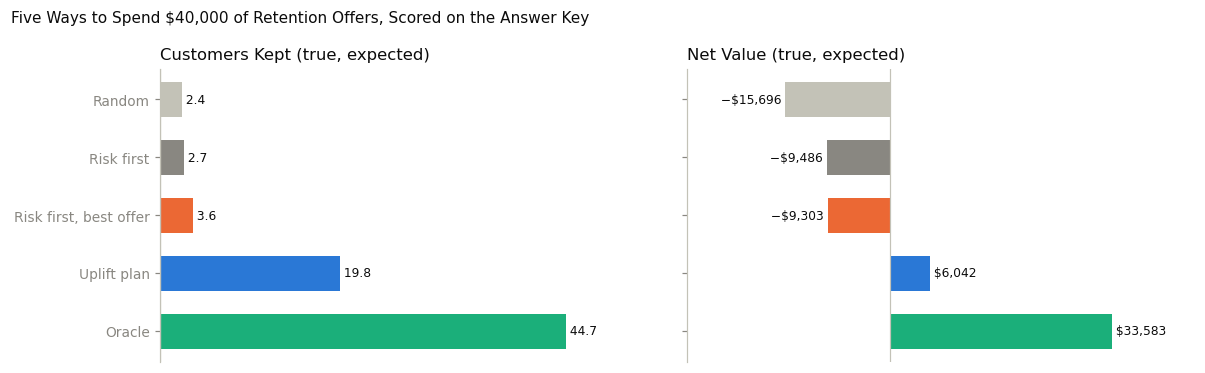

In [9]:
# Plot: Customers Kept and Net Value by Policy
order = ['Random', 'Risk first', 'Risk first, best offer', 'Uplift plan', 'Oracle']
colors = [BASELINE, MUTED, ACCENT2, ACCENT, TEAL]
fig, axes = plt.subplots(1, 2, figsize = (11, 3.4))
for ax, column, fmt, title in [(axes[0], 'customers kept', lambda v: f'{v:.1f}', 'Customers Kept (true, expected)'),
                               (axes[1], 'net value', money, 'Net Value (true, expected)')]:
    values = comparison.loc[order, column]
    ax.barh(order[::-1], values[::-1], color = colors[::-1], height = 0.6)
    for i, v in enumerate(values[::-1]):
        ax.text(v, i, f' {fmt(v)} ' , va = 'center', ha = 'left' if v >= 0 else 'right', fontsize = 8, color = INK)
    ax.axvline(0, color = BASELINE, linewidth = 0.8)
    span = values.max() - min(values.min(), 0)
    ax.set_xlim(values.min() - span * 0.3 if values.min() < 0 else 0, values.max() + span * 0.25)
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)
    ax.set_title(title, loc = 'left')
axes[1].set_yticklabels([])
fig.suptitle(f'Five Ways to Spend ${BUDGET:,} of Retention Offers, Scored on the Answer Key', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>6 · Budget</h2>
<p><strong>Purpose:</strong> Repeats the comparison from &#36;5,000 to &#36;120,000 of exposure, to show how each policy's results change with spending and where more budget stops paying for itself.</p>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The uplift plan's value peaks at &#36;20,000 to &#36;40,000.</strong> Beyond that, each added offer goes to a customer the models are less sure of, and net value falls, turning negative by &#36;120,000. Risk first loses more with every dollar.</li>
<li style="margin-bottom: 0.7em;"><strong>&#36;40,000 is a sound nightly budget.</strong> It sits at the top of the uplift plan's curve: 19.8 customers kept and about &#36;6,000 of net value.</li>
</ol>
</div>

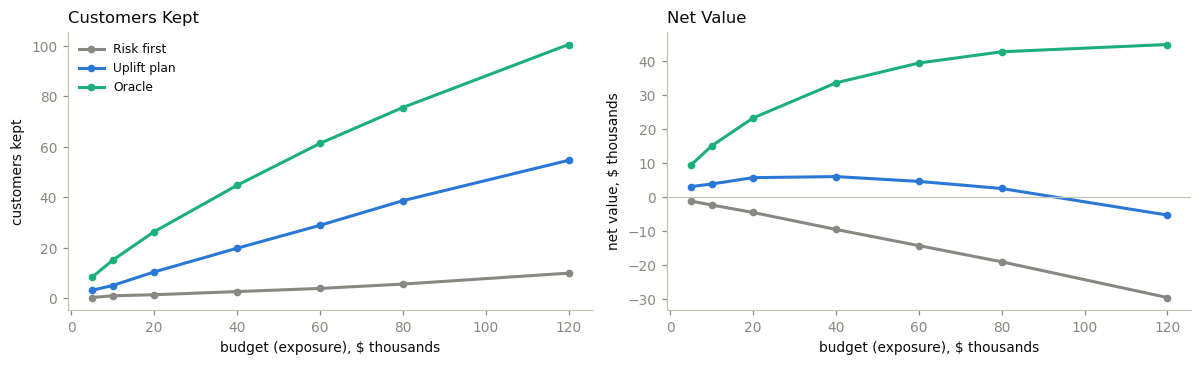

In [10]:
# Plot: Customers Kept and Net Value by Budget
BUDGETS = [5_000, 10_000, 20_000, 40_000, 60_000, 80_000, 120_000]
sweep = pd.DataFrame([{'budget': b, 'policy': name, **true_outcome(plan)}
                      for b in BUDGETS for name, plan in policy_plans(b).items() if name in ('Risk first', 'Uplift plan', 'Oracle')])
fig, axes = plt.subplots(1, 2, figsize = (11, 3.4))
for name, color in [('Risk first', MUTED), ('Uplift plan', ACCENT), ('Oracle', TEAL)]:
    s = sweep[sweep['policy'] == name]
    axes[0].plot(s['budget'] / 1000, s['customers kept'], marker = 'o', markersize = 4, color = color, linewidth = 2, label = name)
    axes[1].plot(s['budget'] / 1000, s['net value'] / 1000, marker = 'o', markersize = 4, color = color, linewidth = 2, label = name)
axes[0].set_ylabel('customers kept')
axes[1].set_ylabel('net value, $ thousands')
axes[1].axhline(0, color = BASELINE, linewidth = 0.8)
for ax in axes:
    ax.set_xlabel('budget (exposure), $ thousands')
axes[0].set_title('Customers Kept', loc = 'left')
axes[1].set_title('Net Value', loc = 'left')
axes[0].legend(frameon = False, fontsize = 8, loc = 'upper left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>7 · Greedy vs Exact</h2>
<p><strong>Purpose:</strong> Checks the fast selection rule the agent uses against the exact best selection, an integer program solved with CBC on the same candidates and budget.</p>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The fast rule is optimal here.</strong> Both choose the same 666 customers, with the same estimated value. With one offer dominating after the gate, ordering by value per dollar is exactly the knapsack's solution; the integer program stays as a check for nights when offers compete.</li>
</ol>
</div>

In [11]:
# Compare Greedy and Exact Selection
started = time.time()
greedy = O.select_greedy(candidates, BUDGET)
greedy_seconds = time.time() - started
started = time.time()
exact = O.select_exact(candidates, BUDGET)
exact_seconds = time.time() - started
display(pd.DataFrame({
    'greedy': {'customers': len(greedy), 'estimated net value': greedy['net_value'].sum(), 'exposure': greedy['exposure'].sum(), 'seconds': greedy_seconds},
    'exact': {'customers': len(exact), 'estimated net value': exact['net_value'].sum(), 'exposure': exact['exposure'].sum(), 'seconds': exact_seconds},
}).T.style.format({'customers': '{:,.0f}', 'estimated net value': money, 'exposure': money, 'seconds': '{:.2f}'}))

,customers,estimated net value,exposure,seconds
greedy,666,"$37,968","$39,960",0.00
exact,666,"$37,968","$39,960",0.80


<hr>
<div>
<h2>8 · Tonight's Plan</h2>
<p><strong>Purpose:</strong> Produces tonight's plan the way the agent will: the guarded selection, with a random 10% of the chosen customers held back so the plan's real effect can be measured.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Holdout.</strong> Held-back customers get nothing tonight. Comparing their churn over the next 90 days with the contacted customers' is an unbiased read of the plan's effect, the check the plan's own estimate can't provide (section 06).</li>
<li style="margin-bottom: 0.7em;"><strong>Files.</strong> <code>outputs/tonight_plan.parquet</code>: each chosen customer's offer, the estimates behind it, the reason from their rep codes, and whether they're held out.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Tonight: 614 discounts, 52 held back.</strong> &#36;36,840 of exposure, about &#36;17,900 expected at the test's acceptance rate. The plan is all discounts: after the gate, the device credit's &#36;200 cost never pays for its estimated effect.</li>
<li style="margin-bottom: 0.7em;"><strong>The top of the list reads like the finding.</strong> Price-reason customers with moderate risk and high value, where the discount's estimated uplift is 4–7 points.</li>
</ol>
</div>

In [12]:
# Plan Tonight
tonight_plan, summary = O.plan_tonight(candidates, BUDGET, seed = SEED)
display(pd.Series(summary).to_frame('tonight'))
display(tonight_plan.head(8)[['account_id', 'offer', 'reason', 'p_churn_90', 'uplift', 'value', 'net_value', 'holdout']]
        .style.format({'p_churn_90': '{:.1%}', 'uplift': '{:.2%}', 'value': money, 'net_value': money}))
print(save_output(tonight_plan, 'tonight_plan'), f'· {len(tonight_plan):,} customers')

,tonight
customers,614
held_out,52
exposure,36840.0
expected_cost,17901.52
model_customers_kept,23.7
by_offer,{'discount': 614}


,account_id,offer,reason,p_churn_90,uplift,value,net_value,holdout
0,98858,discount,price,7.9%,6.52%,"$2,759",$151,False
1,76474,discount,price,5.1%,4.00%,"$4,200",$139,False
2,77595,discount,price,9.7%,6.28%,"$2,569",$132,False
3,96879,discount,price,4.9%,4.61%,"$3,468",$131,False
4,18499,discount,price,6.0%,4.54%,"$3,498",$130,False
5,82040,discount,price,6.5%,4.81%,"$3,265",$128,False
6,49832,discount,price,5.3%,4.28%,"$3,627",$126,False
7,93422,discount,price,5.9%,4.61%,"$3,336",$125,False


outputs/tonight_plan.parquet · 666 customers


<hr>
<div>
<h2>Section 04 Summary</h2>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The headline.</strong> For the same &#36;40,000, targeting by uplift keeps 19.8 customers and earns &#36;6,042; targeting the riskiest customers keeps 2.7 and loses &#36;9,486. The customers most likely to leave are not the ones an offer can keep.</li>
<li style="margin-bottom: 0.7em;"><strong>Estimates can't be taken at face value.</strong> A plan built straight from them forecast &#36;65,490 and lost &#36;6,484. Three guardrails grounded in pre-launch evidence fixed it: use only offers the test proved, cost offers at the test's acceptance rate, and cap exposure rather than expected cost.</li>
<li style="margin-bottom: 0.7em;"><strong>Measure, don't forecast.</strong> Even the guarded plan's own estimate is optimistic, so every night holds back 10% of the chosen customers; their churn against the contacted customers' is the plan's real effect (section 06).</li>
<li style="margin-bottom: 0.7em;"><strong>Handoff.</strong> Tonight's 666 customers, their offers, and the numbers behind each go to the agent (section 05), which writes the messages and asks for approval.</li>
</ol>
</div>